<a href="https://colab.research.google.com/github/Megh8py/synent-task1-datacleaning_and_preprocessing_titanic-Megh_Chauhan/blob/main/task1_titanic_data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1: Data Cleaning & Preprocessing
## Synent Technologies – Data Science Internship

**Dataset:** Titanic Dataset  
**Objective:** Clean and prepare raw data for analysis  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Load Dataset

Download the Titanic dataset from Kaggle:  
https://www.kaggle.com/competitions/titanic/data

Place `train.csv` in the same directory as this notebook, or use the seaborn built-in loader below.

In [2]:

df = sns.load_dataset('titanic')

print(f'Dataset Shape: {df.shape}')
df.head(10)

Dataset Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


## 3. Initial Exploration

In [3]:
print('=== Dataset Info ===')
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
print('=== Summary Statistics ===')
df.describe(include='all')

=== Summary Statistics ===


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


=== Missing Values ===
             Missing Count  Missing %
deck                   688      77.22
age                    177      19.87
embarked                 2       0.22
embark_town              2       0.22


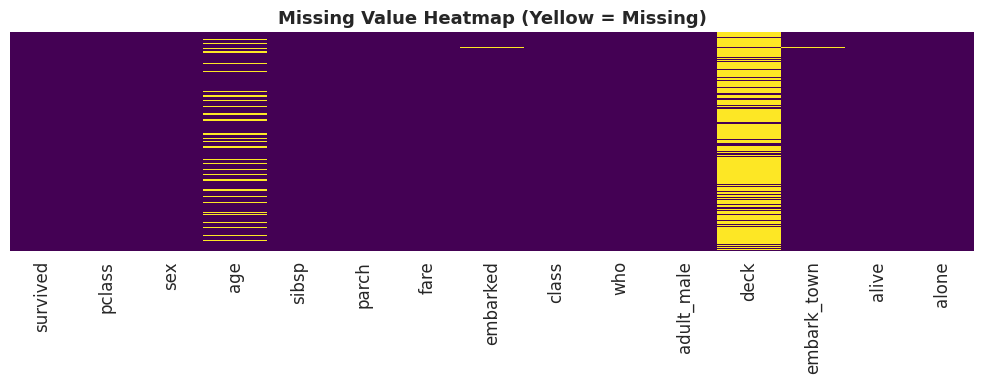

In [5]:
# Missing values – count and percentage
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('=== Missing Values ===')
print(missing_df)

# Visualize
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Value Heatmap (Yellow = Missing)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('missing_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Handle Missing Values

In [6]:
# --- Age: fill with median grouped by class and sex ---
age_before = df['age'].isnull().sum()

df['age'] = df.groupby(['pclass', 'sex'])['age'].transform(
    lambda x: x.fillna(x.median())
)

age_after = df['age'].isnull().sum()
print(f'Age missing before: {age_before} → after: {age_after}')

Age missing before: 177 → after: 0


In [7]:
# --- Embarked: fill with mode ---
emb_before = df['embarked'].isnull().sum()
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)
print(f'Embarked missing before: {emb_before} → after: {df["embarked"].isnull().sum()}')

# --- Deck / Cabin: too many missing values, drop ---
cols_to_drop = [col for col in ['deck', 'cabin'] if col in df.columns]
if cols_to_drop:
    df.drop(columns=cols_to_drop, inplace=True)
    print(f'Dropped high-missing columns: {cols_to_drop}')

# --- Fare: fill with median ---
if df['fare'].isnull().sum() > 0:
    df['fare'].fillna(df['fare'].median(), inplace=True)
    print('Fare: filled with median')

print(f'\nRemaining missing values: {df.isnull().sum().sum()}')

Embarked missing before: 2 → after: 0
Dropped high-missing columns: ['deck']

Remaining missing values: 2


## 5. Remove Duplicates

In [8]:
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
print(f'Rows before: {before} | Rows after: {after} | Duplicates removed: {before - after}')

Rows before: 891 | Rows after: 773 | Duplicates removed: 118


## 6. Convert Data Types

In [9]:
print('Data types before conversion:')
print(df.dtypes)

# Convert survived to int if boolean
if df['survived'].dtype == bool:
    df['survived'] = df['survived'].astype(int)

# Convert pclass to category
df['pclass'] = df['pclass'].astype('category')

# Convert sex and embarked to category
for col in ['sex', 'embarked', 'who', 'embark_town', 'alive', 'class']:
    if col in df.columns:
        df[col] = df[col].astype('category')

# Ensure age and fare are float
df['age'] = df['age'].astype(float)
df['fare'] = df['fare'].astype(float)

print('\nData types after conversion:')
print(df.dtypes)

Data types before conversion:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
embark_town      object
alive            object
alone              bool
dtype: object

Data types after conversion:
survived          int64
pclass         category
sex            category
age             float64
sibsp             int64
parch             int64
fare            float64
embarked       category
class          category
who            category
adult_male         bool
embark_town    category
alive          category
alone              bool
dtype: object


## 7. Rename Columns

In [10]:
# Standardize to snake_case (already mostly done by seaborn)
df.rename(columns={
    'pclass':   'passenger_class',
    'sibsp':    'siblings_spouses',
    'parch':    'parents_children',
    'embarked': 'embarkation_port'
}, inplace=True)

print('Renamed columns:')
print(df.columns.tolist())

Renamed columns:
['survived', 'passenger_class', 'sex', 'age', 'siblings_spouses', 'parents_children', 'fare', 'embarkation_port', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']


## 8. Feature Engineering

In [11]:
# Family size
df['family_size'] = df['siblings_spouses'] + df['parents_children'] + 1
df['is_alone'] = (df['family_size'] == 1).astype(int)

# Age groups
df['age_group'] = pd.cut(df['age'],
                         bins=[0, 12, 18, 35, 60, 100],
                         labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])

# Fare bins
df['fare_tier'] = pd.qcut(df['fare'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

print('New features added: family_size, is_alone, age_group, fare_tier')
df[['age', 'age_group', 'fare', 'fare_tier', 'siblings_spouses', 'parents_children', 'family_size', 'is_alone']].head(10)

New features added: family_size, is_alone, age_group, fare_tier


,age,age_group,fare,fare_tier,siblings_spouses,parents_children,family_size,is_alone
0,22.0,Young Adult,7.2500,Low,1,0,2,0
1,38.0,Adult,71.2833,Very High,1,0,2,0
2,26.0,Young Adult,7.9250,Low,0,0,1,1
3,35.0,Young Adult,53.1000,Very High,1,0,2,0
4,35.0,Young Adult,8.0500,Low,0,0,1,1
5,25.0,Young Adult,8.4583,Medium,0,0,1,1
6,54.0,Adult,51.8625,Very High,0,0,1,1
7,2.0,Child,21.0750,High,3,1,5,0
8,27.0,Young Adult,11.1333,Medium,0,2,3,0
9,14.0,Teen,30.0708,High,1,0,2,0


## 9. Encode Categorical Variables

In [12]:
# Label encode binary columns
df['sex_encoded'] = df['sex'].map({'male': 0, 'female': 1})
df['port_encoded'] = df['embarkation_port'].map({'S': 0, 'C': 1, 'Q': 2})

print('Encoded: sex → sex_encoded, embarkation_port → port_encoded')
df[['sex', 'sex_encoded', 'embarkation_port', 'port_encoded']].head(5)

Encoded: sex → sex_encoded, embarkation_port → port_encoded


,sex,sex_encoded,embarkation_port,port_encoded
0,male,0,S,0
1,female,1,C,1
2,female,1,S,0
3,female,1,S,0
4,male,0,S,0


## 10. Visualizations on Clean Data

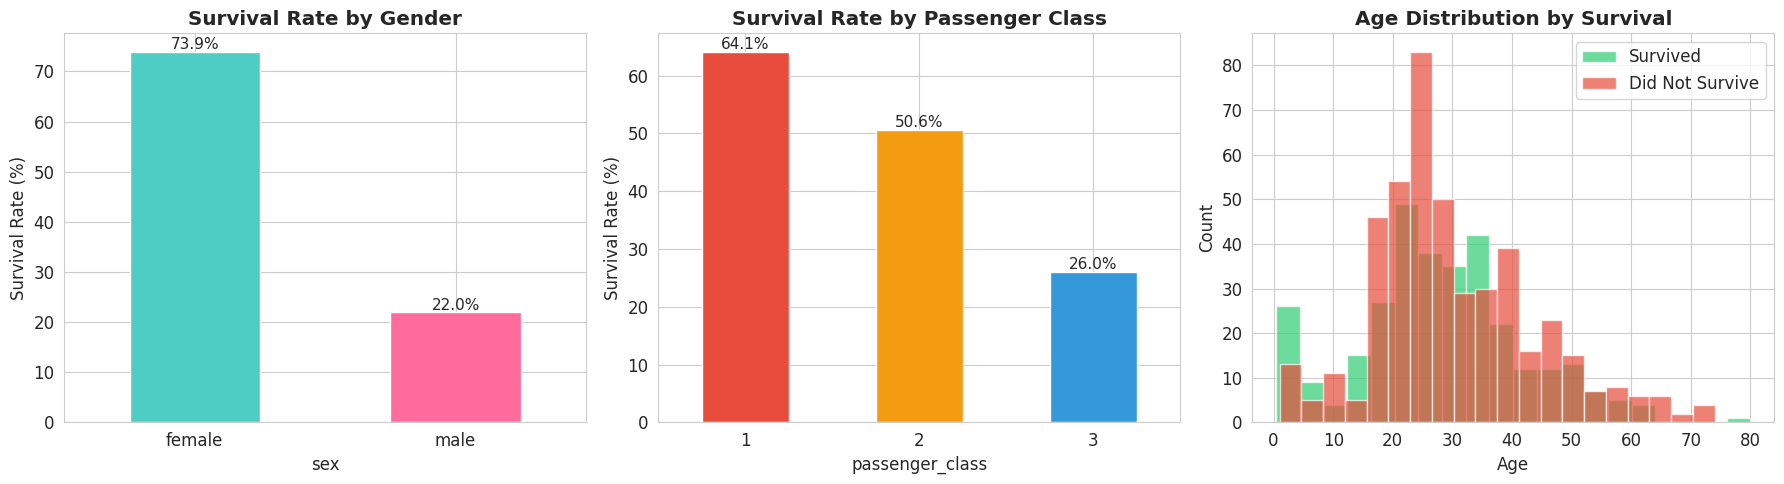

In [13]:
# Survival rate by gender and class
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Survival by gender
survival_sex = df.groupby('sex')['survived'].mean() * 100
survival_sex.plot(kind='bar', ax=axes[0], color=['#4ECDC4', '#FF6B9D'], edgecolor='white')
axes[0].set_title('Survival Rate by Gender', fontweight='bold')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].tick_params(axis='x', rotation=0)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=11)

# Survival by class
survival_class = df.groupby('passenger_class')['survived'].mean() * 100
survival_class.plot(kind='bar', ax=axes[1], color=['#E74C3C', '#F39C12', '#3498DB'], edgecolor='white')
axes[1].set_title('Survival Rate by Passenger Class', fontweight='bold')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].tick_params(axis='x', rotation=0)
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=11)

# Age distribution by survival
df[df['survived'] == 1]['age'].hist(ax=axes[2], bins=20, alpha=0.7, color='#2ECC71', label='Survived')
df[df['survived'] == 0]['age'].hist(ax=axes[2], bins=20, alpha=0.7, color='#E74C3C', label='Did Not Survive')
axes[2].set_title('Age Distribution by Survival', fontweight='bold')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.savefig('survival_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

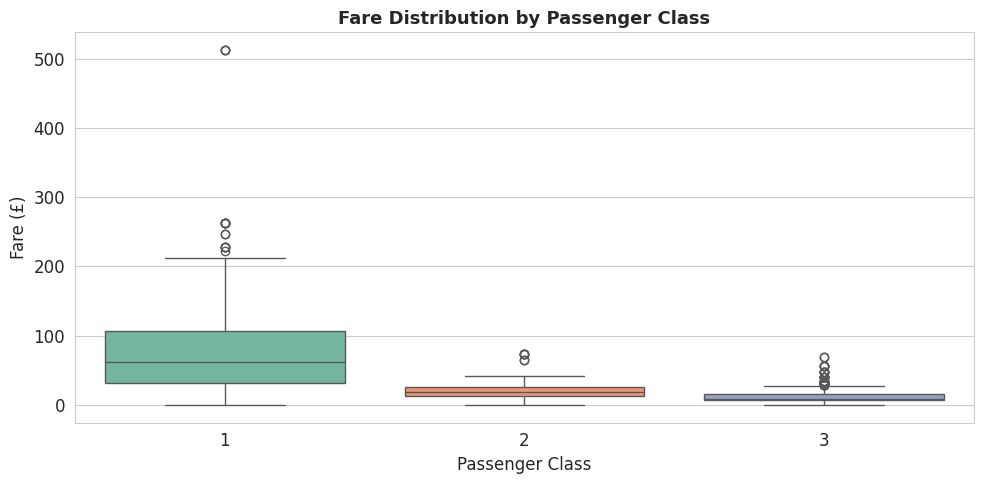

In [14]:
# Fare distribution by class (boxplot)
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='passenger_class', y='fare', palette='Set2')
plt.title('Fare Distribution by Passenger Class', fontsize=13, fontweight='bold')
plt.xlabel('Passenger Class')
plt.ylabel('Fare (£)')
plt.tight_layout()
plt.savefig('fare_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

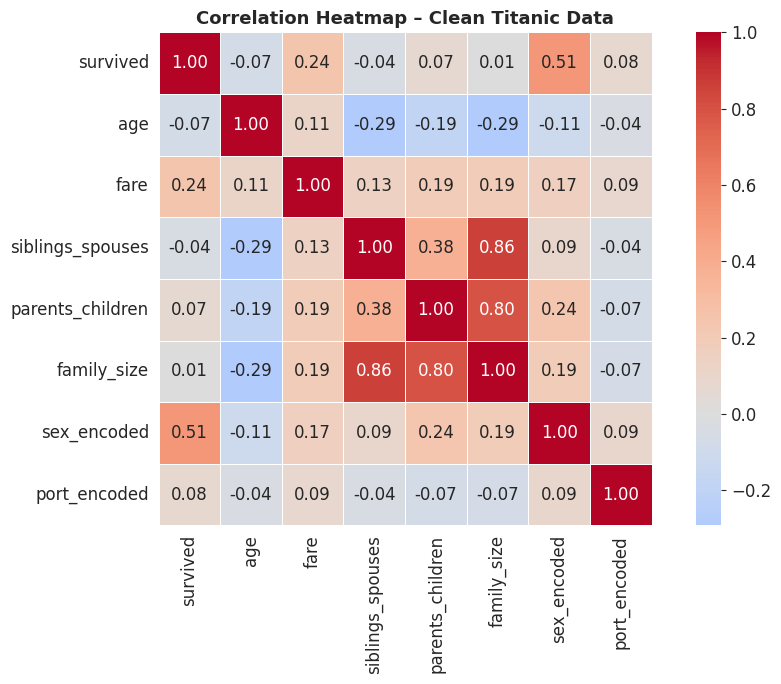

In [15]:
# Correlation heatmap on numeric columns
numeric_cols = ['survived', 'age', 'fare', 'siblings_spouses', 'parents_children', 'family_size', 'sex_encoded', 'port_encoded']
plt.figure(figsize=(10, 7))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap – Clean Titanic Data', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Final Clean Dataset

In [16]:
print('=== Final Dataset Overview ===')
print(f'Shape: {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Duplicates: {df.duplicated().sum()}')
print()
df.info()

=== Final Dataset Overview ===
Shape: (773, 20)
Missing values: 2
Duplicates: 0

<class 'pandas.core.frame.DataFrame'>
Index: 773 entries, 0 to 890
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   survived          773 non-null    int64   
 1   passenger_class   773 non-null    category
 2   sex               773 non-null    category
 3   age               773 non-null    float64 
 4   siblings_spouses  773 non-null    int64   
 5   parents_children  773 non-null    int64   
 6   fare              773 non-null    float64 
 7   embarkation_port  773 non-null    category
 8   class             773 non-null    category
 9   who               773 non-null    category
 10  adult_male        773 non-null    bool    
 11  embark_town       771 non-null    category
 12  alive             773 non-null    category
 13  alone             773 non-null    bool    
 14  family_size       773 non-null    int64   
 15

In [17]:
# Save clean dataset
df.to_csv('titanic_cleaned.csv', index=False)
print('Clean dataset saved to titanic_cleaned.csv')
df.head(10)

Clean dataset saved to titanic_cleaned.csv


,survived,passenger_class,sex,age,siblings_spouses,parents_children,fare,embarkation_port,class,who,adult_male,embark_town,alive,alone,family_size,is_alone,age_group,fare_tier,sex_encoded,port_encoded
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,2,0,Young Adult,Low,0,0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,2,0,Adult,Very High,1,1
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,1,1,Young Adult,Low,1,0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,2,0,Young Adult,Very High,1,0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,1,1,Young Adult,Low,0,0
5,0,3,male,25.0,0,0,8.4583,Q,Third,man,True,Queenstown,no,True,1,1,Young Adult,Medium,0,2
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,Southampton,no,True,1,1,Adult,Very High,0,0
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,Southampton,no,False,5,0,Child,High,0,0
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,Southampton,yes,False,3,0,Young Adult,Medium,1,0
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,Cherbourg,yes,False,2,0,Teen,High,1,1


## 12. Key Insights

| Step | Action | Result |
|------|--------|--------|
| Missing Values | Age filled with grouped median (class + sex) | No age nulls remaining |
| Missing Values | Embarked filled with mode | No embarked nulls remaining |
| Missing Values | Deck/Cabin columns dropped (>77% missing) | Columns removed |
| Duplicates | Checked and removed duplicates | 0 duplicate rows |
| Data Types | Converted to category, float, int as appropriate | Correct dtypes throughout |
| Column Renaming | Standardized to descriptive snake_case names | Readable column names |
| Feature Engineering | Added family_size, is_alone, age_group, fare_tier | 4 new useful features |
| Encoding | Encoded sex and embarkation port numerically | Ready for ML models |

### Key Findings
- **Female survival rate (~74%)** was significantly higher than male (~19%)
- **1st class passengers** had the highest survival rate (~63%)
- **Children (age < 12)** had relatively higher survival rates
- **Fare and survival** are positively correlated — higher fare = better chance of survival
- The clean dataset is now **ready for EDA or ML modeling**